# **CLASIFICACIÓN DE CELULAS BENIGNAS Y MALIGNAS EN BASE A ALGORITMO DE APRENDIZAJE SUPERVISADO:**
## *MÁQUINA DE SOPORTE VECTORIAL*

### Repositorio de Machine Learning de la UCI (Asuncion y Newman, 2007) disponible en [http://mlearn.ics.uci.edu/MLRepository.html]
#### **Descripción de variables:**
    

Field name: Description

ID: Clump thickness

Clump: Clump thickness

UnifSize: Uniformity of cell size

UnifShape: Uniformity of cell shape

MargAdh: Marginal adhesion

SingEpiSize: Single epithelial cell size

BareNuc: Bare nuclei

BlandChrom: Bland chromatin

NormNucl: Normal nucleoli

Mit: Mitoses

Class: Benign or malignant


### **1. Carga de librerias y base de datos:**

In [ ]:
import pandas as pd
import pylab as pl
import numpy as np
import scipy.optimize as opt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
%matplotlib inline
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/cell_samples.csv')

In [ ]:
df.head()

,ID,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


### **2. Exploración:**

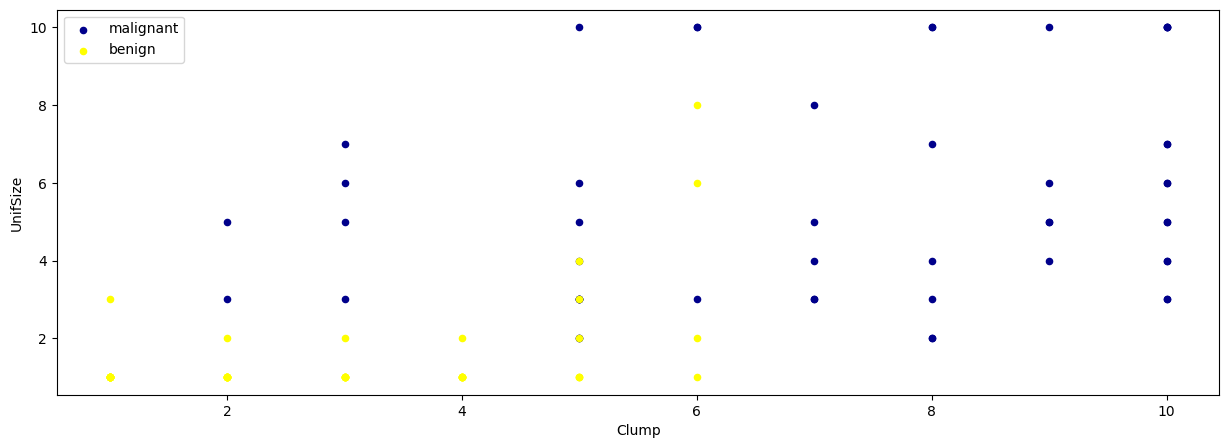

In [ ]:
ax = df[df['Class'] == ][0:50].plot(kind='scatter', x='Class', y='UnifSize', color='DarkBlue', label='malignant',figsize=[15,5]);
df[df['Class'] == 2][0:50].plot(kind='scatter', x='Class', y='UnifSize', color='Yellow', label='benign', ax=ax);

plt.show()

In [ ]:
df.dtypes

ID              int64
Clump           int64
UnifSize        int64
UnifShape       int64
MargAdh         int64
SingEpiSize     int64
BareNuc        object
BlandChrom      int64
NormNucl        int64
Mit             int64
Class           int64
dtype: object

In [ ]:
df.describe()

,ID,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BlandChrom,NormNucl,Mit,Class
count,6.990000e+02,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000
mean,1.071704e+06,4.417740,3.134478,3.207439,2.806867,3.216023,3.437768,2.866953,1.589413,2.689557
std,6.170957e+05,2.815741,3.051459,2.971913,2.855379,2.214300,2.438364,3.053634,1.715078,0.951273
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.706885e+05,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238298e+06,6.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


In [ ]:
df.shape

(699, 11)

##### **Distribución de las variables:**

In [ ]:
cols = ['ID', 'Clump', 'UnifSize', 'UnifShape', 'MargAdh', 'SingEpiSize', 'BareNuc', 'BlandChrom', 'NormNucl', 'Mit', 'Class']

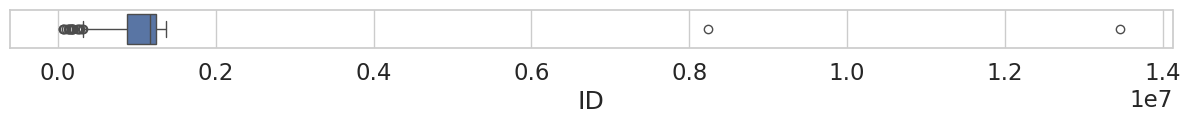

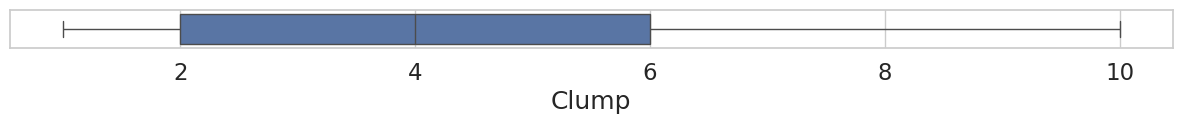

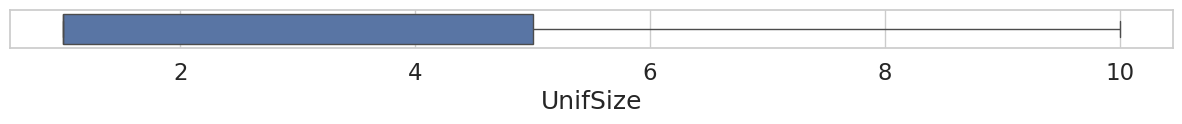

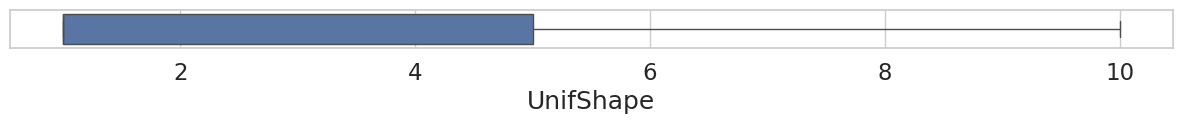

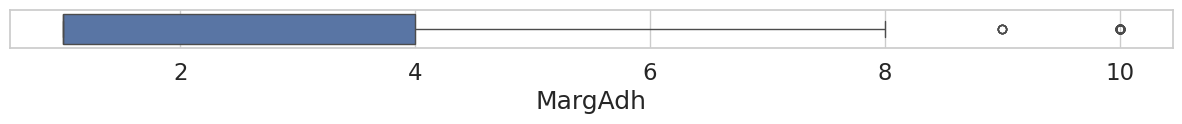

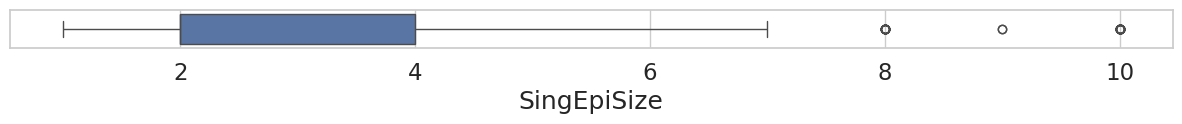

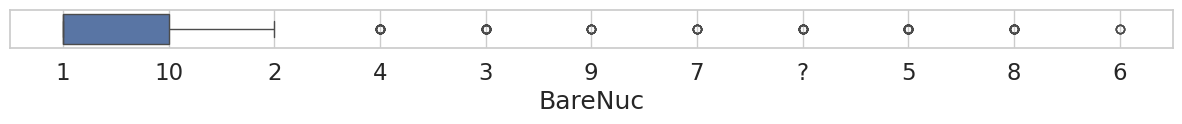

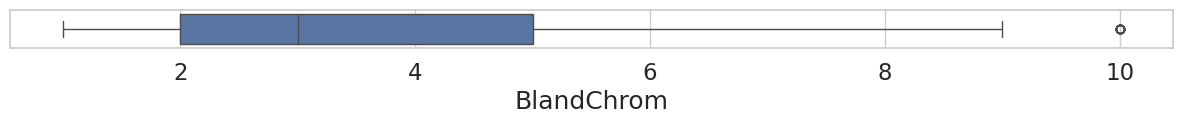

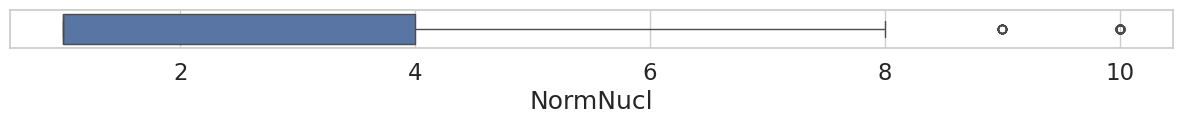

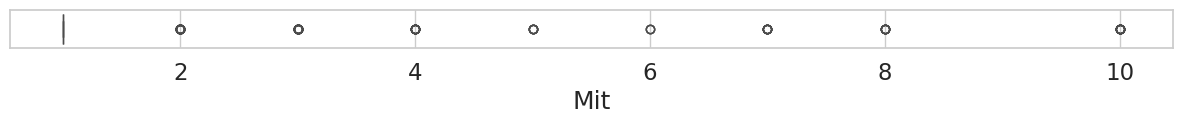

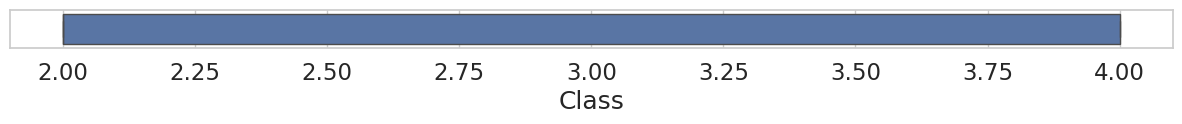

In [ ]:
sns.set(rc={'figure.figsize':(15,0.5)}, font_scale=1.5, style='whitegrid')
for item in cols:
    sns.boxplot(x = df[item], )
    plt.show()

In [ ]:
#Convertir tipo de dato en variable BareNuc:
df = df[pd.to_numeric(df['BareNuc'], errors='coerce').notnull()]
df['BareNuc'] = df['BareNuc'].astype('int')
df.dtypes

<ipython-input-10-a5ffd526a8af>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['BareNuc'] = df['BareNuc'].astype('int')


ID             int64
Clump          int64
UnifSize       int64
UnifShape      int64
MargAdh        int64
SingEpiSize    int64
BareNuc        int64
BlandChrom     int64
NormNucl       int64
Mit            int64
Class          int64
dtype: object

##### **Análisis de valores nulos:**

In [ ]:
df.isnull().sum()

ID             0
Clump          0
UnifSize       0
UnifShape      0
MargAdh        0
SingEpiSize    0
BareNuc        0
BlandChrom     0
NormNucl       0
Mit            0
Class          0
dtype: int64

In [ ]:
#Outliers encontrados en gráfico de bigotes= >8
MargAdh_counts= df["MargAdh"].value_counts().sort_values(ascending=False)
MargAdh_counts

MargAdh
1     393
3      58
2      58
10     55
4      33
8      25
5      23
6      21
7      13
9       4
Name: count, dtype: int64

In [ ]:
#Outliers encontrados en gráfico de bigotes= >7
SingEpiSize_counts= df["SingEpiSize"].value_counts().sort_values(ascending=False)
SingEpiSize_counts

SingEpiSize
2     376
3      71
4      48
1      44
6      40
5      39
10     31
8      21
7      11
9       2
Name: count, dtype: int64

In [ ]:
#Outliers encontrados en gráfico de bigotes= >9
BlandChrom_counts= df["BlandChrom"].value_counts().sort_values(ascending=False)
BlandChrom_counts

BlandChrom
3     161
2     160
1     150
7      71
4      39
5      34
8      28
10     20
9      11
6       9
Name: count, dtype: int64

In [ ]:
#Outliers encontrados en gráfico de bigotes= >9
NormNucl_counts= df["NormNucl"].value_counts().sort_values(ascending=False)
NormNucl_counts

NormNucl
1     432
10     60
3      42
2      36
8      23
6      22
5      19
4      18
7      16
9      15
Name: count, dtype: int64

In [ ]:
#Outliers encontrados en gráfico de bigotes= >1
Mit_counts= df["Mit"].value_counts().sort_values(ascending=False)
Mit_counts

Mit
1     563
2      35
3      33
10     14
4      12
7       9
8       8
5       6
6       3
Name: count, dtype: int64

### **3. Tratamiento de datos:**

##### **Outliers:**

In [ ]:
Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df[cols] < (Q1 - 4 * IQR)) |(df[cols] > (Q3 + 4 * IQR))).any(axis=1)]
df

,ID,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...
692,714039,3,1,1,1,2,1,1,1,1,2
694,776715,3,1,1,1,3,2,1,1,1,2
695,841769,2,1,1,1,2,1,1,1,1,2
697,897471,4,8,6,4,3,4,10,6,1,4


In [ ]:
df.shape

(561, 11)

#### **Análisis de correlaciones para evaluar datos redundantes:**

In [ ]:
from scipy.stats import shapiro
estadistico, p_value= shapiro(df)
print('Estadistico=%.3f, p_value=%.3f' % (estadistico, p_value))

Estadistico=0.327, p_value=0.000


/usr/local/lib/python3.10/dist-packages/scipy/stats/_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


In [ ]:
#Tabla de correlaciones:
Corr=pd.DataFrame(df).corr(method='spearman')
Corr

,ID,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit,Class
ID,1.000000,0.046494,-0.029242,-0.049682,-0.023945,-0.079953,-0.107761,-0.084887,-0.064403,NaN,-0.087927
Clump,0.046494,1.000000,0.565508,0.570879,0.468123,0.485985,0.481229,0.421034,0.455083,NaN,0.569231
UnifSize,-0.029242,0.565508,1.000000,0.848093,0.684568,0.705522,0.722751,0.627611,0.671315,NaN,0.814362
UnifShape,-0.049682,0.570879,0.848093,1.000000,0.654577,0.674267,0.696614,0.602786,0.629519,NaN,0.788459
MargAdh,-0.023945,0.468123,0.684568,0.654577,1.000000,0.588442,0.628385,0.516517,0.553655,NaN,0.699051
SingEpiSize,-0.079953,0.485985,0.705522,0.674267,0.588442,1.000000,0.640240,0.530085,0.606714,NaN,0.699370
BareNuc,-0.107761,0.481229,0.722751,0.696614,0.628385,0.640240,1.000000,0.609275,0.585371,NaN,0.805822
BlandChrom,-0.084887,0.421034,0.627611,0.602786,0.516517,0.530085,0.609275,1.000000,0.570163,NaN,0.677298
NormNucl,-0.064403,0.455083,0.671315,0.629519,0.553655,0.606714,0.585371,0.570163,1.000000,NaN,0.671367
Mit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.drop(["Mit"], axis=1, inplace=True)
df.drop(["ID"], axis=1, inplace=True)

In [ ]:
df.dtypes

Clump          int64
UnifSize       int64
UnifShape      int64
MargAdh        int64
SingEpiSize    int64
BareNuc        int64
BlandChrom     int64
NormNucl       int64
Class          int64
dtype: object

In [ ]:
import numpy as np
from scipy.linalg import svd
U, s, V_transp=svd(df)
s

array([237.35780929,  52.09090897,  45.09185663,  36.44176868,
        35.85934408,  32.67886577,  29.4903312 ,  18.19712655,
        15.93466843])

In [ ]:
rank=np.sum(s>1)

In [ ]:
print ("La matriz tiene rango {}".format(rank))

La matriz tiene rango 9


In [ ]:
df.corr('spearman')['Class'].sort_values()

Clump          0.569231
NormNucl       0.671367
BlandChrom     0.677298
MargAdh        0.699051
SingEpiSize    0.699370
UnifShape      0.788459
BareNuc        0.805822
UnifSize       0.814362
Class          1.000000
Name: Class, dtype: float64

In [ ]:
# Se conservan las 9 variables para el modelado.

In [ ]:
X = df.drop(columns='Class')
y = df['Class']

In [ ]:
class_counts= df["Class"].value_counts()
class_counts

Class
2    429
4    132
Name: count, dtype: int64

### **4. Estandarización y desempeño del modelo de clasificación:**
#### *Maquina de soporte vectorial*

In [ ]:
X= preprocessing.StandardScaler().fit(X).transform(X)
X[0:5]

array([[ 4.46528259e-01, -5.60273612e-01, -6.13407649e-01,
        -5.32859094e-01, -4.23999883e-01, -5.56800587e-01,
        -1.61373571e-03, -4.74609386e-01],
       [ 4.46528259e-01,  5.95290713e-01,  5.57074293e-01,
         1.19258940e+00,  2.33544251e+00,  2.26861264e+00,
        -1.61373571e-03, -6.99652134e-02],
       [-3.43699985e-01, -5.60273612e-01, -6.13407649e-01,
        -5.32859094e-01, -4.23999883e-01, -2.42865784e-01,
        -1.61373571e-03, -4.74609386e-01],
       [ 8.41642381e-01,  2.13604315e+00,  2.11771688e+00,
        -5.32859094e-01,  1.27888596e-01,  3.85003823e-01,
        -1.61373571e-03,  1.95325565e+00],
       [ 5.14141371e-02, -5.60273612e-01, -6.13407649e-01,
         3.29865154e-01, -4.23999883e-01, -5.56800587e-01,
        -1.61373571e-03, -4.74609386e-01]])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=4)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (448, 8) (448,)
Test set: (113, 8) (113,)


##### **Máquina de soporte vectorial con función base radial:**

In [ ]:
from sklearn import svm
svm_radial = svm.SVC(kernel='rbf')
svm_radial.fit(X_train, y_train)

SVC()

In [ ]:
yhat_radial = svm_radial.predict(X_test)
yhat_radial [0:5]

array([2, 2, 2, 4, 2])

##### **Evaluación:**

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import itertools
from sklearn.metrics import f1_score
from sklearn.metrics import jaccard_score

In [ ]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    Esta función imprime y marca la matriz de confusión.
    Se puede aplicar Normalización seteando la variable `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Matriz de confusión, sin normalización')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('Etiqueta True')
    plt.xlabel('Etiqueta predecida')

In [ ]:
print("Avg F1-score: %.10f" % f1_score(y_test, yhat_radial, average='weighted'))
print("Jaccard score: %.10f" % jaccard_score(y_test, yhat_radial, average="weighted"))

Avg F1-score: 0.9736056642
Jaccard score: 0.9489812719


In [ ]:
# Computar la matriz de confusión
cnf_matrix = confusion_matrix(y_test, yhat_radial, labels=[2,4])
np.set_printoptions(precision=2)

print (classification_report(y_test, yhat_radial))


              precision    recall  f1-score   support

           2       0.99      0.98      0.98        85
           4       0.93      0.96      0.95        28

    accuracy                           0.97       113
   macro avg       0.96      0.97      0.96       113
weighted avg       0.97      0.97      0.97       113



In [ ]:
cnf_matrix

array([[83,  2],
       [ 1, 27]])

##### **Resultados: Máquina de soporte vectorial con ajuste radial**

1.   83 células benignas clasificadas correctamente.
2.   **1 célula maligna clasificada erroneamente.**
1.   27 células malignas clasificadas correctamente.
2.   2 célula benigna clasificada erroneamente.





##### **Máquina de soporte vectorial con función lineal:**

In [ ]:
svm_lineal = svm.SVC(kernel='linear')
svm_lineal.fit(X_train, y_train)
yhat_lineal = svm_lineal.predict(X_test)
print("Avg F1-score: %.10f" % f1_score(y_test, yhat_lineal, average='weighted'))
print("Jaccard score: %.10f" % jaccard_score(y_test, yhat_lineal, average="weighted"))

Avg F1-score: 0.9825006902
Jaccard score: 0.9657817109


In [ ]:
# Computar la matriz de confusión
cnf_matrix_lineal = confusion_matrix(y_test, yhat_lineal, labels=[2,4])
np.set_printoptions(precision=2)

print (classification_report(y_test, yhat_lineal))

              precision    recall  f1-score   support

           2       1.00      0.98      0.99        85
           4       0.93      1.00      0.97        28

    accuracy                           0.98       113
   macro avg       0.97      0.99      0.98       113
weighted avg       0.98      0.98      0.98       113



In [ ]:
cnf_matrix_lineal

array([[83,  2],
       [ 0, 28]])

##### **Resultado: Máquina de soporte vectorial con ajuste lineal**

1.   83 células benignas clasificadas correctamente.
2.   **0 células malignas clasificadas erroneamente.**
1.   28 células malignas clasificadas correctamente.
2.   2 células benignas clasificadas erroneamente.

##### **Máquina de soporte vectorial con ajuste polinómico:**

In [ ]:
svm_poly = svm.SVC(kernel='poly')
svm_poly.fit(X_train, y_train)
yhat_poly = svm_poly.predict(X_test)
print("Avg F1-score: %.10f" % f1_score(y_test, yhat_poly, average='weighted'))
print("Jaccard score: %.10f" % jaccard_score(y_test, yhat_poly, average="weighted"))

Avg F1-score: 0.9641520508
Jaccard score: 0.9316309263


In [ ]:
# Computar la matriz de confusión
cnf_matrix_poly = confusion_matrix(y_test, yhat_poly, labels=[2,4])
np.set_printoptions(precision=2)

print (classification_report(y_test, yhat_poly))

              precision    recall  f1-score   support

           2       0.97      0.99      0.98        85
           4       0.96      0.89      0.93        28

    accuracy                           0.96       113
   macro avg       0.96      0.94      0.95       113
weighted avg       0.96      0.96      0.96       113



In [ ]:
cnf_matrix_poly

array([[84,  1],
       [ 3, 25]])

##### **Resultado: Máquina de soporte vectorial con ajuste polinómico**

1.   84 células benignas clasificadas correctamente.
2.   **3 células malignas clasificadas erroneamente.**
1.   25 células malignas clasificadas correctamente.
2.   1 célula benigna clasificada erroneamente.

##### **Máquina de soporte vectorial con función sigmoide:**

In [ ]:
svm_sig = svm.SVC(kernel='sigmoid')
svm_sig.fit(X_train, y_train)
yhat_sig = svm_sig.predict(X_test)
print("Avg F1-score: %.10f" % f1_score(y_test, yhat_sig, average='weighted'))
print("Jaccard score: %.10f" % jaccard_score(y_test, yhat_sig, average="weighted"))

Avg F1-score: 0.9646017699
Jaccard score: 0.9323771742


In [ ]:
# Computar la matriz de confusión
cnf_matrix_sig = confusion_matrix(y_test, yhat_sig, labels=[2,4])
np.set_printoptions(precision=2)

print (classification_report(y_test, yhat_sig))

              precision    recall  f1-score   support

           2       0.98      0.98      0.98        85
           4       0.93      0.93      0.93        28

    accuracy                           0.96       113
   macro avg       0.95      0.95      0.95       113
weighted avg       0.96      0.96      0.96       113



In [ ]:
cnf_matrix_sig

array([[83,  2],
       [ 2, 26]])

##### **Resultados: Máquina de soporte vectorial con ajuste sigmoide**

1.   83 células benignas clasificadas correctamente.
2.   **2 células malignas clasificadas erroneamente.**
1.   26 células malignas clasificadas correctamente.
2.   2 células benignas clasificadas erroneamente.

#### **Conclusión:**
El clasificador elegido fue la máquina de soporte vectorial con ajuste lineal, pues fue el que arrojó la mejor clasificación de células malignas.

### **5. Optimización del modelo elegido:**

In [ ]:
#Definición del grid de busqueda
from sklearn.model_selection import GridSearchCV
from sklearn import svm


In [ ]:
svm_model = svm.SVC(kernel='linear')

In [ ]:
# Definir el espacio de búsqueda de hiperparámetros
param_grid = {
    'C': [0.1, 1, 10, 100],  # Parámetro de regularización

}
# Inicializar GridSearchCV
grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid, cv=5, n_jobs=-1)

# Entrenar el modelo
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(kernel='linear'), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100]})

In [ ]:
# Mejores hiperparámetros encontrados
print("Mejores hiperparámetros:", grid_search.best_params_)

# Precisión del mejor modelo en el conjunto de prueba
print("Precisión del mejor modelo en el conjunto de prueba:", grid_search.best_estimator_.score(X_test, y_test))

Mejores hiperparámetros: {'C': 1}
Precisión del mejor modelo en el conjunto de prueba: 0.9823008849557522


In [ ]:
import joblib

# Guardar el modelo entrenado
joblib.dump(grid_search.best_estimator_, 'svm_model.pkl')

['svm_model.pkl']

In [ ]:
# Cargar el modelo
loaded_model = joblib.load('svm_model.pkl')

predictions = loaded_model.predict(X_test)

In [ ]:
svm_model.fit(X_train,y_train)
svm_model_hat= svm_model.predict(X_test)
print("Avg F1-score: %.10f" % f1_score(y_test, svm_model_hat, average='weighted'))
print("Jaccard score: %.10f" % jaccard_score(y_test, svm_model_hat, average="weighted"))

Avg F1-score: 0.9825006902
Jaccard score: 0.9657817109


In [ ]:
# Computar la matriz de confusión
cnf_matrix_lineal = confusion_matrix(y_test, svm_model_hat, labels=[2,4])
np.set_printoptions(precision=2)

print (classification_report(y_test, svm_model_hat))

              precision    recall  f1-score   support

           2       1.00      0.98      0.99        85
           4       0.93      1.00      0.97        28

    accuracy                           0.98       113
   macro avg       0.97      0.99      0.98       113
weighted avg       0.98      0.98      0.98       113



In [ ]:
cnf_matrix_lineal

array([[83,  2],
       [ 0, 28]])

#### **Resultados luego de la optimización:**

1.   83 células benignas clasificadas correctamente.
2.   **0 células malignas clasificadas erroneamente.**
1.   28 células malignas clasificadas correctamente.
2.   2 células benignas clasificadas erroneamente.

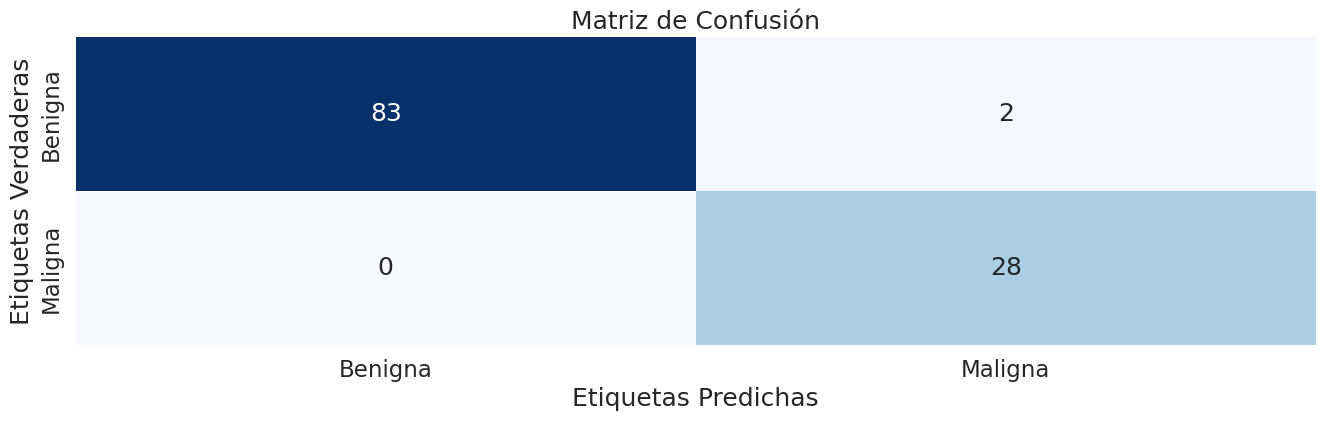

In [ ]:
# Definir etiquetas de clase
class_labels = ['Benigna', 'Maligna']


# Graficar la matriz de confusión con etiquetas
plt.figure(figsize=(16, 4))  # Tamaño ajustado
sns.heatmap(cnf_matrix_lineal, annot=True, cmap='Blues', fmt='g', cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Etiquetas Predichas')
plt.ylabel('Etiquetas Verdaderas')
plt.title('Matriz de Confusión')
plt.show()

##### **El resultado de la optimización a través de la búsqueda de hiperparámetros arrojó un valor de C=1. Dicho parámetro controla el equilibrio entre la complejidad del modelo y la penalización por errores de clasificación durante el proceso de entrenamiento la cual, en este caso, corresponde a la configuración por defecto de la libreria scikit-learn para la máquina de soporte vectorial con ajuste lineal.**

In [ ]:


import joblib

# Cargar el modelo entrenado
loaded_model = joblib.load('svm_model.pkl')

print("Por favor, ingrese los valores de las variables:")
variable_names = ['Clump', 'NormNucl', 'BlandChrom', 'MargAdh','SingEpiSize', 'UnifShape','BareNuc','UnifSize']  # Reemplaza con los nombres de tus variables
variables = []
for name in variable_names:
    value = float(input(f"Ingrese el valor de {name}:"))
    variables.append(value)


variables_array = [variables]

prediction = loaded_model.predict(variables_array)

print("La predicción es:", prediction)

Por favor, ingrese los valores de las variables:
Ingrese el valor de Clump:1
Ingrese el valor de NormNucl:2
Ingrese el valor de BlandChrom:3
Ingrese el valor de MargAdh:4
Ingrese el valor de SingEpiSize:5
Ingrese el valor de UnifShape:6
Ingrese el valor de BareNuc:7
Ingrese el valor de UnifSize:8
La predicción es: [4]


##### **Interpretación de resultado:**
output 2= **Benigna**
outout 4= **Maligna**

##### **Para volver a utilizar el código rápido con ingreso manual de entrada de datos, por favor ejecute la celda apretando control + enter para que le vuelvan a solicitar nuevos datos de entrada.**